In [27]:
# Etape 1 : EDA et préparation de données

Distribution de x_wins :
 x_wins
1    0.755262
0    0.244738
Name: proportion, dtype: float64

Distribution de is_draw :
 is_draw
0    0.817994
1    0.182006
Name: proportion, dtype: float64


C:\Users\ainar\AppData\Local\Temp\ipykernel_27072\16087207.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_draw', data=df, palette='viridis').set_title('Distribution : Match Nul')


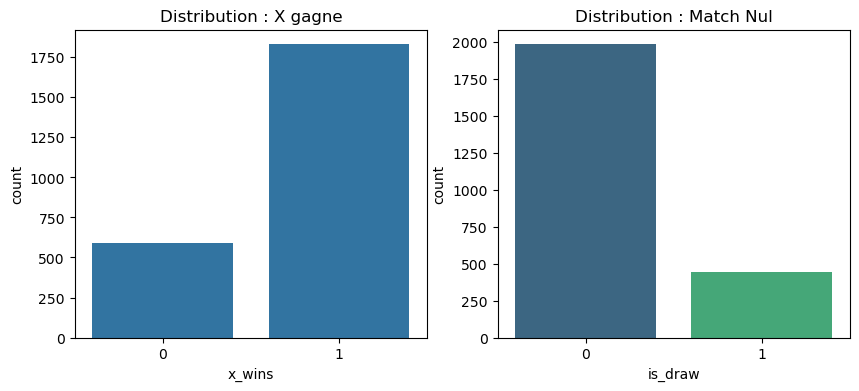


Fréquence des cases occupées par X lors d'une victoire :
 c0_x    569
c1_x    521
c2_x    569
c3_x    521
c4_x    592
c5_x    521
c6_x    569
c7_x    521
c8_x    569
dtype: int64


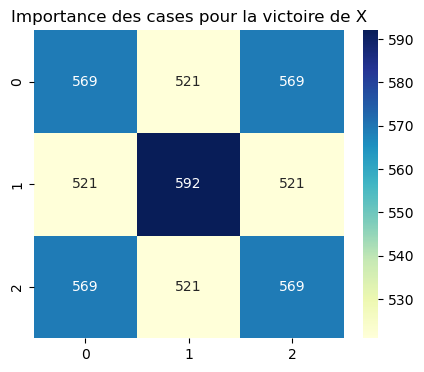

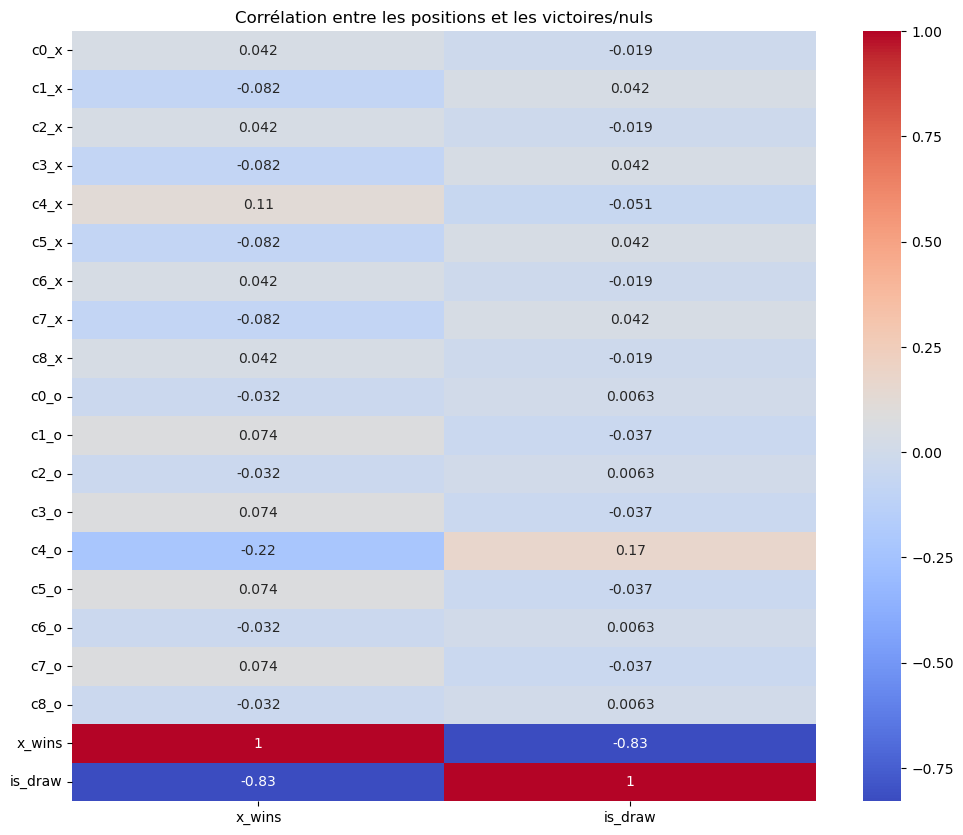

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 0. Charger le fichier généré
df = pd.read_csv('ressources/tic_tac_toe_dataset.csv')

# --- 1. Distribution de x_wins et is_draw (Équilibre) ---
print("Distribution de x_wins :\n", df['x_wins'].value_counts(normalize=True))
print("\nDistribution de is_draw :\n", df['is_draw'].value_counts(normalize=True))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='x_wins', data=df).set_title('Distribution : X gagne')
plt.subplot(1, 2, 2)
sns.countplot(x='is_draw', data=df, palette='viridis').set_title('Distribution : Match Nul')
plt.show()

# --- 2. Quelle case est la plus occupée par X quand il gagne ? ---
# On filtre les lignes où x_wins == 1
wins_df = df[df['x_wins'] == 1]
# On fait la somme des colonnes c0_x à c8_x
x_positions_wins = wins_df[[f'c{i}_x' for i in range(9)]].sum()

print("\nFréquence des cases occupées par X lors d'une victoire :\n", x_positions_wins)

# Visualisation sous forme de grille 3x3 (Heatmap du plateau)
grid_wins = x_positions_wins.values.reshape(3, 3)
plt.figure(figsize=(5, 4))
sns.heatmap(grid_wins, annot=True, fmt="g", cmap="YlGnBu")
plt.title("Importance des cases pour la victoire de X")
plt.show()

# --- 3. Corrélation entre features et cibles (Heatmap) ---
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
# On se concentre sur la corrélation avec les cibles uniquement
sns.heatmap(correlation_matrix[['x_wins', 'is_draw']], annot=True, cmap='coolwarm')
plt.title("Corrélation entre les positions et les victoires/nuls")
plt.show()


--- ÉVALUATION : Modèle x_wins ---
Accuracy : 0.7876
F1-Score : 0.8761


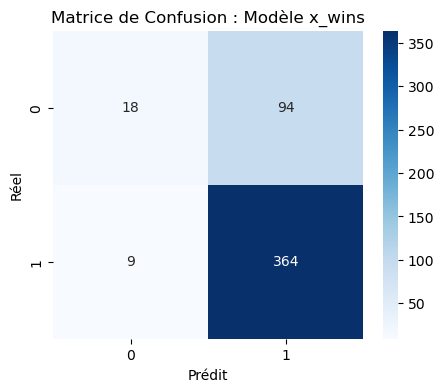


--- ÉVALUATION : Modèle is_draw ---
Accuracy : 0.8268
F1-Score : 0.0000


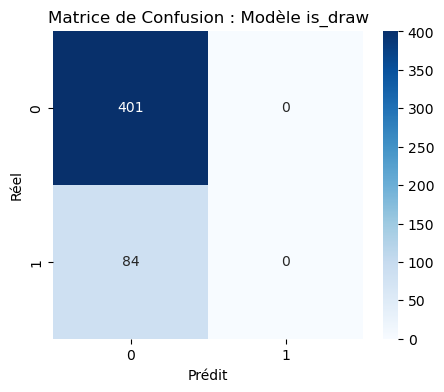

In [29]:
# Etape 2 : Baseline : Régression Logistique (×2)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement et séparation
df = pd.read_csv('ressources/tic_tac_toe_dataset.csv')
X = df.drop(['x_wins', 'is_draw'], axis=1)
y_wins = df['x_wins']
y_draw = df['is_draw']

# Split 80% train / 20% test (on utilise le même split pour comparer équitablement)
X_train, X_test, y_train_w, y_test_w = train_test_split(X, y_wins, test_size=0.2, random_state=42)
_, _, y_train_d, y_test_d = train_test_split(X, y_draw, test_size=0.2, random_state=42)

# 2. Entraînement des modèles
model_wins = LogisticRegression(max_iter=1000)
model_draw = LogisticRegression(max_iter=1000)

model_wins.fit(X_train, y_train_w)
model_draw.fit(X_train, y_train_d)

# 3. Prédictions
pred_w = model_wins.predict(X_test)
pred_d = model_draw.predict(X_test)

# --- FONCTION D'ÉVALUATION ---
def evaluate(y_true, y_pred, title):
    print(f"\n--- ÉVALUATION : {title} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matrice de Confusion : {title}')
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.show()

evaluate(y_test_w, pred_w, "Modèle x_wins")
evaluate(y_test_d, pred_d, "Modèle is_draw")


--- ÉVALUATION : Decision Tree : x_wins ---
Accuracy : 0.7443
F1-Score : 0.8394


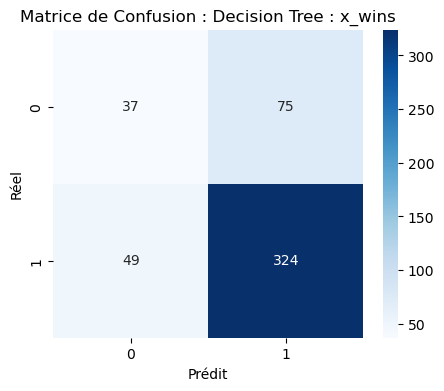


--- ÉVALUATION : Random Forest : is_draw ---
Accuracy : 0.9155
F1-Score : 0.6870


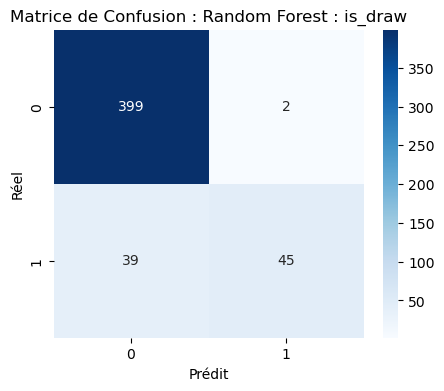


--- ÉVALUATION : MLP : is_draw ---
Accuracy : 0.9196
F1-Score : 0.7547


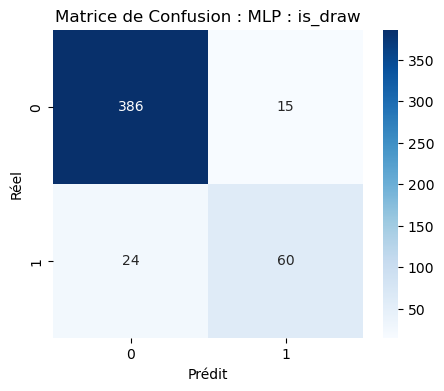

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# --- AJOUT DES MODÈLES AVANCÉS ---

# 1. Decision Tree
dt_wins = DecisionTreeClassifier(max_depth=5)
dt_wins.fit(X_train, y_train_w)
evaluate(y_test_w, dt_wins.predict(X_test), "Decision Tree : x_wins")

# 2. Random Forest (Le plus robuste)
rf_draw = RandomForestClassifier(n_estimators=100)
rf_draw.fit(X_train, y_train_d)
evaluate(y_test_d, rf_draw.predict(X_test), "Random Forest : is_draw")

# 3. MLP (Réseau de Neurones - Le plus puissant)
mlp_draw = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000)
mlp_draw.fit(X_train, y_train_d)
evaluate(y_test_d, mlp_draw.predict(X_test), "MLP : is_draw")

In [31]:
import joblib
joblib.dump(model_wins, 'ia_model_wins.pkl')
joblib.dump(model_draw, 'ia_model_draw.pkl')

['ia_model_draw.pkl']

In [32]:
# Etape 3 : Modèle avancée

=== Decision Tree - X Wins ===
Accuracy: 0.7443298969072165
F1 Score: 0.8393782383419689


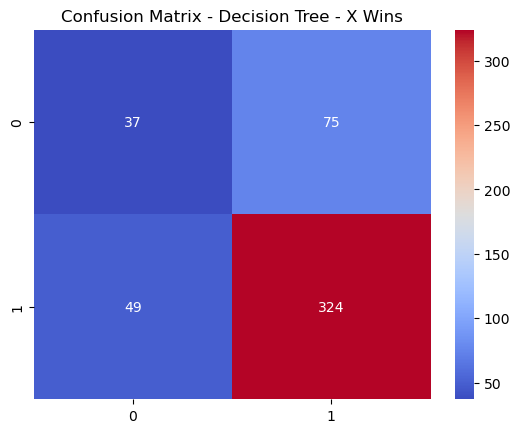

=== Decision Tree - Draw ===
Accuracy: 0.8391752577319588
F1 Score: 0.3157894736842105


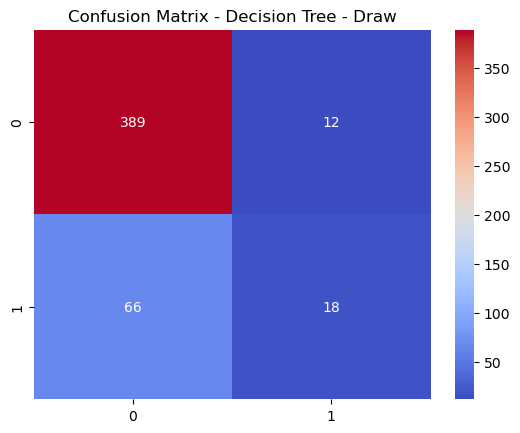

=== Random Forest - X Wins ===
Accuracy: 0.8783505154639175
F1 Score: 0.9246487867177522


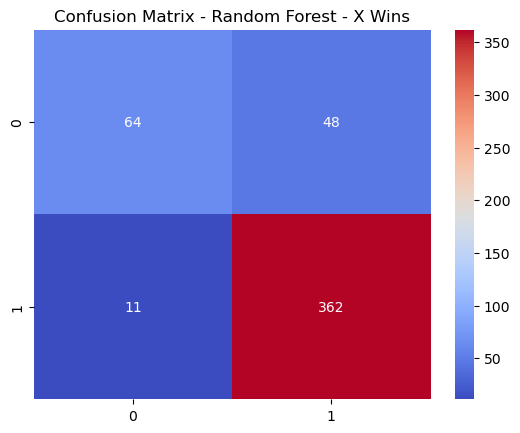

=== Random Forest - Draw ===
Accuracy: 0.9051546391752577
F1 Score: 0.6290322580645161


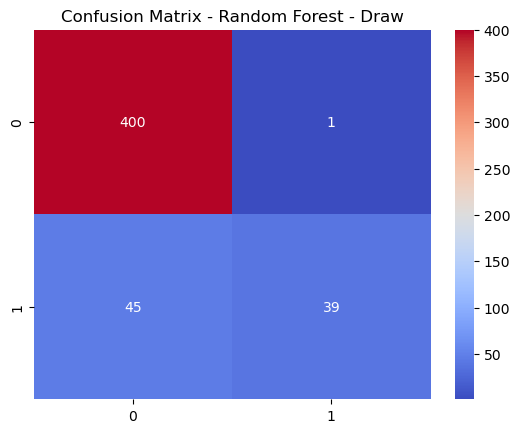

=== Gradient Boosting - X Wins ===
Accuracy: 0.8391752577319588
F1 Score: 0.9002557544757033


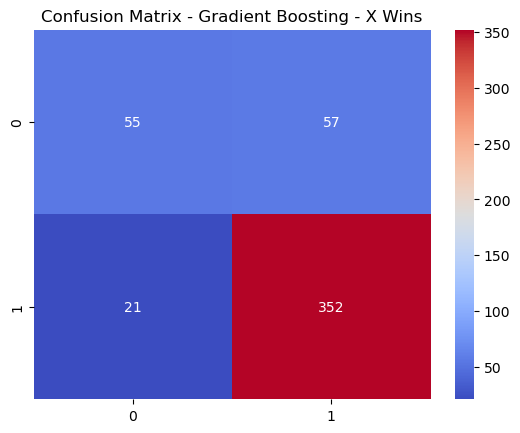

=== Gradient Boosting - Draw ===
Accuracy: 0.8762886597938144
F1 Score: 0.5238095238095238


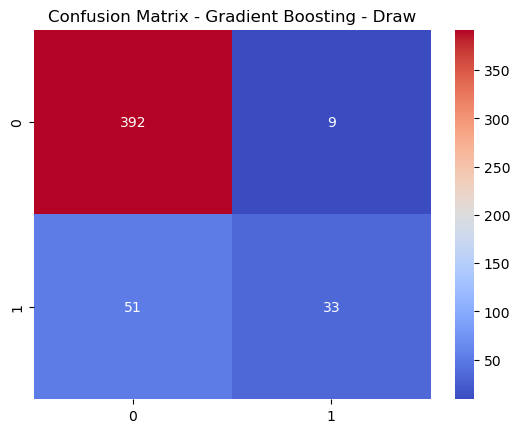

=== MLP - X Wins ===
Accuracy: 0.9154639175257732
F1 Score: 0.9446693657219973


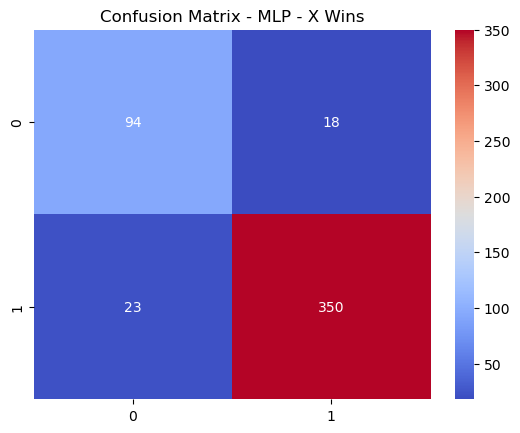

=== MLP - Draw ===
Accuracy: 0.9484536082474226
F1 Score: 0.8466257668711656


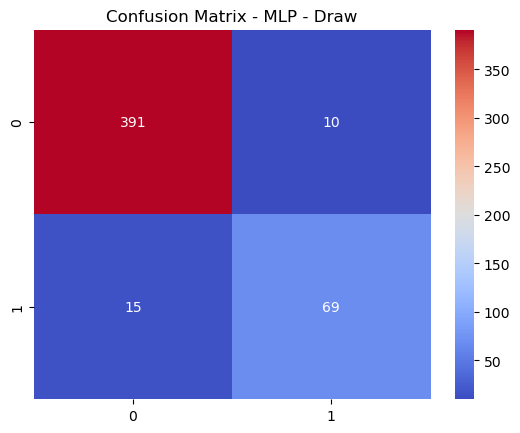

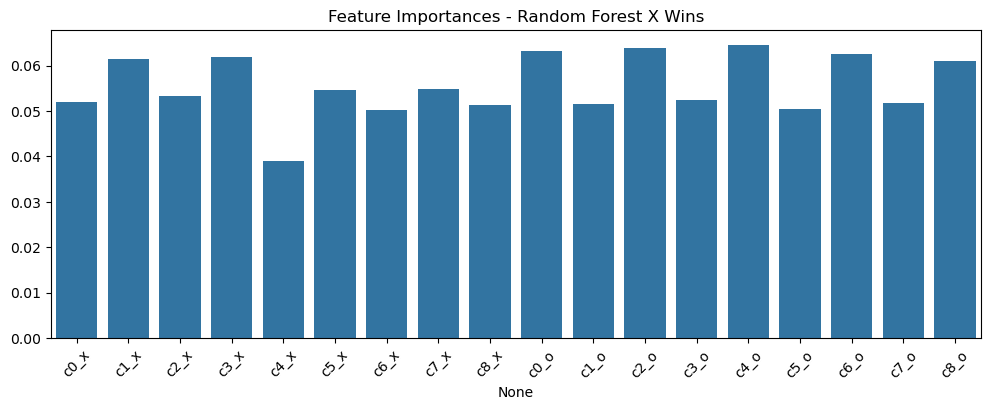

['mlp_is_draw.pkl']

In [33]:
# ----------------------------
# 1 Import des bibliothèques
# ----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np
import joblib

# ----------------------------
# 2 Charger le dataset
# ----------------------------
df = pd.read_csv("ressources/tic_tac_toe_dataset.csv")

X = df.drop(columns=["x_wins", "is_draw"])
y_win = df["x_wins"]
y_draw = df["is_draw"]

# Split train/test
X_train, X_test, y_win_train, y_win_test = train_test_split(X, y_win, test_size=0.2, random_state=42)
_, _, y_draw_train, y_draw_test = train_test_split(X, y_draw, test_size=0.2, random_state=42)

# ----------------------------
# 3 Fonction pour entraîner et évaluer
# ----------------------------
def train_evaluate(model, X_train, X_test, y_train, y_test, title):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"=== {title} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f"Confusion Matrix - {title}")
    plt.show()
    
    return model

# ----------------------------
# 4 Entraîner les modèles avancés
# ----------------------------

# Decision Tree
dt_win = train_evaluate(DecisionTreeClassifier(max_depth=5, random_state=42), 
                        X_train, X_test, y_win_train, y_win_test, "Decision Tree - X Wins")
dt_draw = train_evaluate(DecisionTreeClassifier(max_depth=5, random_state=42), 
                         X_train, X_test, y_draw_train, y_draw_test, "Decision Tree - Draw")

# Random Forest
rf_win = train_evaluate(RandomForestClassifier(n_estimators=100, random_state=42),
                        X_train, X_test, y_win_train, y_win_test, "Random Forest - X Wins")
rf_draw = train_evaluate(RandomForestClassifier(n_estimators=100, random_state=42),
                         X_train, X_test, y_draw_train, y_draw_test, "Random Forest - Draw")

# Gradient Boosting
gb_win = train_evaluate(GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
                        X_train, X_test, y_win_train, y_win_test, "Gradient Boosting - X Wins")
gb_draw = train_evaluate(GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
                         X_train, X_test, y_draw_train, y_draw_test, "Gradient Boosting - Draw")

# MLP (Neural Network)
mlp_win = train_evaluate(MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
                         X_train, X_test, y_win_train, y_win_test, "MLP - X Wins")
mlp_draw = train_evaluate(MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
                          X_train, X_test, y_draw_train, y_draw_test, "MLP - Draw")

# ----------------------------
# 5 Visualiser l'importance des features (Random Forest X Wins)
# ----------------------------
feat_importances = rf_win.feature_importances_
plt.figure(figsize=(12,4))
sns.barplot(x=X.columns, y=feat_importances)
plt.title("Feature Importances - Random Forest X Wins")
plt.xticks(rotation=45)
plt.show()

# ----------------------------
# 6 Sauvegarder les modèles pour l'interface
# ----------------------------
joblib.dump(rf_win, "model_x_wins.pkl")
joblib.dump(rf_draw, "model_is_draw.pkl")
joblib.dump(mlp_win, "mlp_x_wins.pkl")
joblib.dump(mlp_draw, "mlp_is_draw.pkl")
